In [1]:
# Automatic Google Colab setup: clones the repo to access the .py module
# and the dataset in this folder (no effect when run locally).
import sys

if "google.colab" in sys.modules:
    import os
    if not os.path.exists("machine-learning-UFMG"):
        get_ipython().system('git clone -q https://github.com/wdasilvamf/machine-learning-UFMG.git')
    os.chdir("machine-learning-UFMG/1-Base-Algorithms/05-MLP-Hyperparameter-Search")
    get_ipython().system('pip install -q openpyxl')


# MLP Hyperparameter Search (activation x neurons)

Translated from `DESAFIO01_FUNCAO_MLP_keras.R` and `DESAFIO01_FUNCAO_MLP_neuralnet.R`.

The two original scripts solve the same challenge (fitting `funcao.xlsx`)
with different frameworks (Keras and `neuralnet`), testing combinations of
activation function and number of neurons, with several repeats per
configuration. This notebook unifies both into a single `scikit-learn`
experiment, preserving the core idea: **compare configurations not just by
average error, but also by stability (variance) across repeats**.

## Theory: why repeat each configuration?

Training an MLP with a stochastic optimizer (`adam`) depends on the random
initialization of the weights. A single run might land in a bad (or good)
local minimum just by luck. Repeating each configuration (here, 5x) lets us
estimate:

- **Mean RMSE**: the configuration's expected performance;
- **RMSE standard deviation**: how much the result varies across runs.

A configuration with a good mean RMSE but a *high* standard deviation is a
risky bet — it may just have gotten a lucky random initialization. A
configuration is only genuinely trustworthy when it has **both** a low mean
RMSE *and* a low standard deviation; the latter is what tells us the good
result isn't a fluke.

### What is a random seed, and why use a different one per repeat?

Computers don't generate truly random numbers — they use a deterministic
formula (a pseudo-random number generator) that only *looks* random. The
**seed** is that formula's starting point: the same seed always produces
the exact same sequence of numbers; a different seed produces a different
sequence. Here, `MLPRegressor(random_state=seed)` uses the seed to draw the
network's initial weights before training starts.

This is precisely why each repeat uses a **different** seed
(`seed = random_state_base + repeat`): if all 5 repeats used the *same*
seed, the initial weights — and therefore the entire optimization path and
final result — would be identical every time. The 5 "repeats" would
collapse into 5 copies of the same run, `rmse_std_dev` would come out as
exactly zero, and we'd have a false sense that the configuration is
perfectly stable, when in fact we never actually tested its sensitivity to
initialization. Different seeds give 5 genuinely different starting points,
so the measured variance reflects the real variability of the method.


In [2]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.exceptions import ConvergenceWarning

from mlp_hyperparameter_search import load_data, run_experiment, summarize

# Small MLPs with few iterations don't always meet the 'adam' solver's
# convergence criterion -- expected in this exploratory experiment.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

plt.rcParams["figure.figsize"] = (8, 5)


## Data and search space

- **Activation functions**: `relu`, `tanh`, `logistic` (scikit-learn's name
  for the sigmoid/logistic function used in both original scripts).
- **Hidden-layer neurons**: 5, 10, 20 — a range common to both original R
  scripts' choices (`c(2,10,20)` in the Keras script, `c(5,10,15,20,25)` in
  the `neuralnet` script).
- **Repeats per configuration**: 5, as in both original scripts.


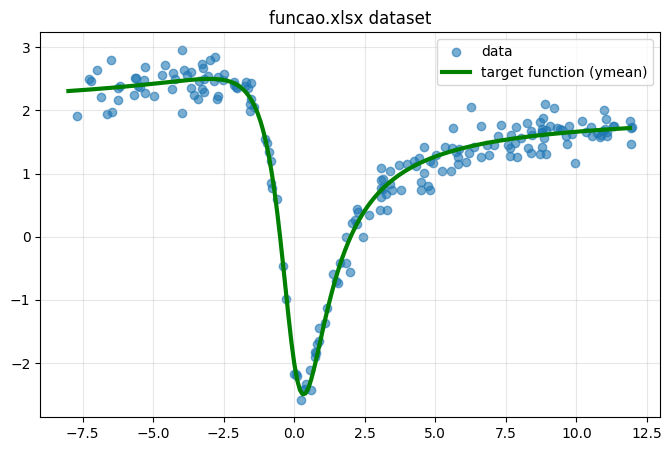

In [3]:
dt = load_data("data/funcao.xlsx")
x = dt["x"].to_numpy(dtype=float)
y = dt["y"].to_numpy(dtype=float)

plt.scatter(x, y, color="tab:blue", alpha=0.6, label="data")
plt.plot(dt["xgrd"], dt["ymean"], color="green", lw=3, label="target function (ymean)")
plt.legend()
plt.grid(alpha=0.3)
plt.title("funcao.xlsx dataset")
plt.show()


In [4]:
results = run_experiment(
    x, y,
    activations=["relu", "tanh", "logistic"],
    hidden_sizes=[5, 10, 20],
    n_repeats=5,
    max_iter=2000,
)
results[["activation", "hidden_size", "repeat", "rmse", "r_squared"]].head()


,activation,hidden_size,repeat,rmse,r_squared
0,relu,5,0,0.831561,0.564244
1,relu,5,1,0.885793,0.505554
2,relu,5,2,0.456782,0.868516
3,relu,5,3,0.808565,0.588012
4,relu,5,4,0.947821,0.433882


## Error (RMSE) distribution per configuration

Equivalent to the boxplot generated in `DESAFIO01_FUNCAO_MLP_keras.R`: lower
boxes indicate lower average error; narrower boxes indicate higher
stability across repeats.


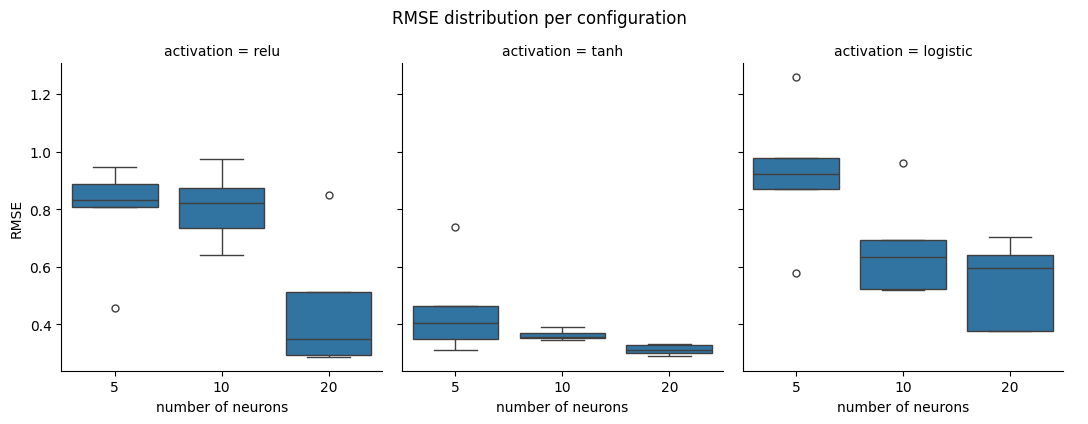

In [5]:
g = sns.catplot(
    data=results, x="hidden_size", y="rmse", col="activation",
    kind="box", color="tab:blue", height=4, aspect=0.9,
)
g.set_axis_labels("number of neurons", "RMSE")
g.figure.suptitle("RMSE distribution per configuration", y=1.05)
plt.show()


## Predictions per configuration, split by number of neurons

The original approach (overlaying all 45 predictions, colored only by
activation function) hid the factor that matters most here: **number of
neurons** (the boxplot above already shows it moves RMSE more than
activation does). This chart splits by number of neurons (panels, like the
boxplot) and shows only each configuration's median-RMSE run — so
activations become comparable within the same neuron count, without the
noise of 45 overlapping lines.


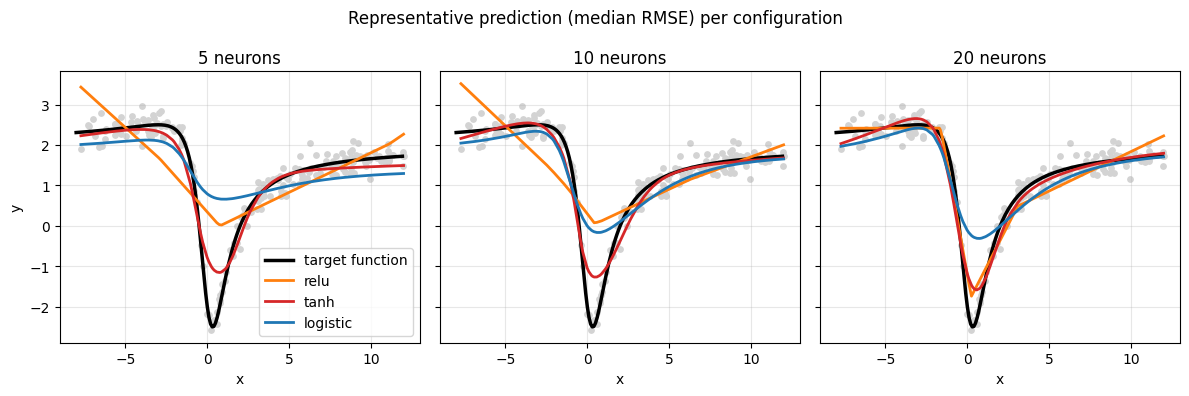

In [6]:
order = x.argsort()
colors = {"relu": "tab:orange", "tanh": "tab:red", "logistic": "tab:blue"}
hidden_sizes = sorted(results["hidden_size"].unique())

fig, axes = plt.subplots(1, len(hidden_sizes), figsize=(4 * len(hidden_sizes), 4), sharey=True)

for ax, hs in zip(axes, hidden_sizes):
    subset = results[results["hidden_size"] == hs]
    ax.scatter(x, y, color="lightgray", zorder=1, s=15)
    ax.plot(dt["xgrd"], dt["ymean"], color="black", lw=2.5, zorder=2, label="target function")

    for activation, color in colors.items():
        config = subset[subset["activation"] == activation]
        # pick the median-RMSE repeat (representative, without the noise of averaging 5 together)
        median_run = config.iloc[(config["rmse"] - config["rmse"].median()).abs().argsort().iloc[0]]
        ax.plot(x[order], median_run["y_pred"][order], color=color, lw=2, label=activation)

    ax.set_title(f"{hs} neurons")
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("y")
axes[0].legend()
fig.suptitle("Representative prediction (median RMSE) per configuration")
plt.tight_layout()
plt.show()


## `tanh` vs. `logistic`: why does the choice of activation matter here?

$$\tanh(z) = \frac{2}{1+e^{-2z}} - 1 \quad \text{(output between -1 and 1, zero-centered)}$$
$$\text{logistic}(z) = \frac{1}{1+e^{-z}} \quad \text{(output between 0 and 1, always positive)}$$

The key difference: `tanh` is **zero-centered** (can output negative or
positive values); `logistic` **never outputs a negative value** — every
hidden neuron's activation is always > 0.

Why this matters for our target function: it dips down to about -2.5 (see
the scatter plot above). With `tanh`, hidden neurons can directly represent
negative values, so the output layer (`w2`) only needs relatively simple
weights to combine those activations into the dip. With `logistic`, every
hidden neuron only ever outputs a number between 0 and 1 (always positive)
— for the network to "reach down" to -2.5, it depends entirely on `w2`
having sufficiently negative weights to flip and pull down that combination
of always-positive numbers. That's more work for the optimizer to find, and
with few neurons (5) there's little slack left to compensate — which is why
`logistic` falls behind, especially in the smaller configurations.

There's a related side effect: since `logistic`'s output never crosses
zero, the gradients flowing backward during training tend to keep the same
sign for a given input pattern, which makes optimization more "zig-zaggy"
and slow — a well-documented issue with non-zero-centered activations.
`tanh`, being symmetric, doesn't suffer from this.


## Interpreting the metrics: summary table

Mean RMSE ranks configurations by performance; RMSE standard deviation
shows stability. The ideal configuration minimizes RMSE **and** has low
variance — a configuration with a good mean RMSE but high variance is a
risky bet in production.


In [7]:
summary = summarize(results)
summary


,activation,hidden_size,mean_rmse,rmse_std_dev,mean_r2
8,tanh,20,0.312563,0.017335,0.938284
7,tanh,10,0.363858,0.018577,0.916397
6,tanh,5,0.453094,0.169566,0.856136
5,relu,20,0.457609,0.236340,0.839880
2,logistic,20,0.538012,0.153102,0.805777
1,logistic,10,0.666455,0.180195,0.703735
3,relu,5,0.786104,0.191777,0.592042
4,relu,10,0.808594,0.127630,0.579771
0,logistic,5,0.920707,0.243502,0.435917


## Conclusion

This systematic search shows that `tanh` with more neurons (20) tends to
produce the lowest mean RMSE with relatively low variance on this dataset,
while `logistic`/sigmoid with few neurons has the worst performance and
highest instability — consistent with sigmoid's stronger saturation for
inputs outside a narrow range, and its lack of zero-centering.

This notebook series covered the full progression of the course's first
lesson: linear regression via gradient descent -> MLP with manual
backpropagation -> MLP via a library (scikit-learn) -> regularization ->
hyperparameter search. The next applied case studies (CNNs, RNN/LSTM/GRU,
NLP) are mapped out from the following lessons' material and will be added
as new items under `1-Base-Algorithms/`.
